# Computer Prices — Regression Challenge

**Goal.** Predict `price` from hardware specifications, minimising RMSE on a
secret test set, while satisfying the challenge's overfitting, reproducibility
and explainability criteria.

**How to read this notebook.** It tells the story end to end: audit, then
exploration, then the experiments that decided the model, then the final model,
the official overfitting rule and the SHAP analysis.

The exhaustive sweeps live in `experiments/exp*.py` and their results in
`experiments/results.csv`; this notebook re-runs a representative subset live
so every claim can be checked, and loads the full history where re-running all
of it would take an hour.

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

from src.config import RANDOM_SEED, TARGET
from src.utils import set_seed

set_seed(RANDOM_SEED)
print("seed fixed at", RANDOM_SEED)

seed fixed at 42


## 1. Loading the data

In [2]:
from src.data import load_raw

df = load_raw()
print(f"shape: {df.shape}")
df.head()

shape: (80000, 34)


,ID,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,3813,Laptop,Acer,Acer Creator HGG,2020,macOS,Ultrabook,Intel,Intel i5-12462,2,6,12,2.2,3.0,AMD,RX 6000 50,1,4,8,NVMe,256,2,VA,14.0,1920x1080,120,80,65,0,Wi-Fi 7,5.2,1.57,12,1046.99
1,99183,Desktop,ASUS,ASUS Creator 4FF,2020,Windows,ATX,Intel,Intel i5-12752,2,8,16,2.6,3.4,NVIDIA,RTX 40 50,1,4,8,NVMe,256,3,LED,27.0,2560x1440,60,0,0,450,Wi-Fi 6,5.1,10.00,48,894.99
2,80737,Laptop,Apple,Apple Pro XOU,2024,macOS,Ultrabook,Apple,Apple M3 Pro,4,14,14,2.6,3.5,Apple,Apple Integrated,2,2,32,NVMe,256,1,Mini-LED,14.0,2560x1600,165,60,45,0,Wi-Fi 5,5.2,2.37,24,2281.99
3,65674,Laptop,Apple,Apple Think RUD,2025,Windows,Workstation,Apple,Apple M3 Pro,4,12,12,2.6,3.5,Apple,Apple Integrated,3,2,32,SSD,1024,1,QLED,13.3,1920x1080,60,56,120,0,Wi-Fi 6,5.2,1.12,24,2608.99
4,53670,Desktop,Dell,Dell Arena MK6,2022,Windows,Micro-ATX,AMD,AMD Ryzen 7 3564,5,18,36,3.2,4.1,Intel,Arc A700,4,4,64,NVMe,1024,3,Mini-LED,24.0,1920x1080,90,0,0,1200,Wi-Fi 6,5.0,9.00,24,1933.99


## 2. Dataset audit

Before any modelling: types, missing values, cardinality, duplicates.

In [3]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "nunique": df.nunique(dropna=True),
})
audit["pct_unique"] = (audit["nunique"] / len(df) * 100).round(2)
audit

,dtype,n_missing,nunique,pct_unique
ID,int64,0,80000,100.00
device_type,str,0,2,0.00
brand,str,0,10,0.01
model,str,0,79352,99.19
release_year,int64,0,8,0.01
os,str,0,4,0.00
form_factor,str,0,10,0.01
cpu_brand,str,0,3,0.00
cpu_model,str,0,25308,31.64
cpu_tier,int64,0,6,0.01


In [4]:
print("full-row duplicates          :", df.duplicated().sum())
print("duplicates ignoring ID       :", df.drop(columns=['ID']).duplicated().sum())
feat = [c for c in df.columns if c not in ('ID', TARGET)]
print("duplicates on features only  :", df[feat].duplicated().sum())
print("ID unique                    :", df['ID'].is_unique, "| range:", df['ID'].min(), "-", df['ID'].max())
print("total missing cells          :", int(df.isna().sum().sum()))

full-row duplicates          : 0


duplicates ignoring ID       : 0
duplicates on features only  : 0
ID unique                    : True | range: 0 - 99999
total missing cells          : 0


No missing values and no duplicates at all. Every row is a unique combination of
features, which also means the irreducible noise cannot be estimated by
comparing repeated specifications — it has to be inferred from model behaviour
instead (section 8).

### Is `ID` informative?

`ID` is unique and spans 0–99,999 while only 80,000 rows are present. That is
consistent with the development set being a random subset of a larger file, but
that remains a **hypothesis about the data, not a fact about the challenge**, and
no modelling decision below depends on it. What matters is the check that `ID`
carries no signal, so it can be dropped rather than exploited.

In [5]:
print("Spearman(ID, price):", round(df[['ID', TARGET]].corr(method='spearman').iloc[0, 1], 5))
df.groupby(pd.qcut(df['ID'], 10, labels=False))[TARGET].mean().round(1).rename("mean price by ID decile")

Spearman(ID, price): 0.00266


ID
0    1927.5
1    1927.6
2    1921.8
3    1925.7
4    1937.3
5    1938.7
6    1920.8
7    1932.9
8    1929.1
9    1935.1
Name: mean price by ID decile, dtype: float64

## 3. The target

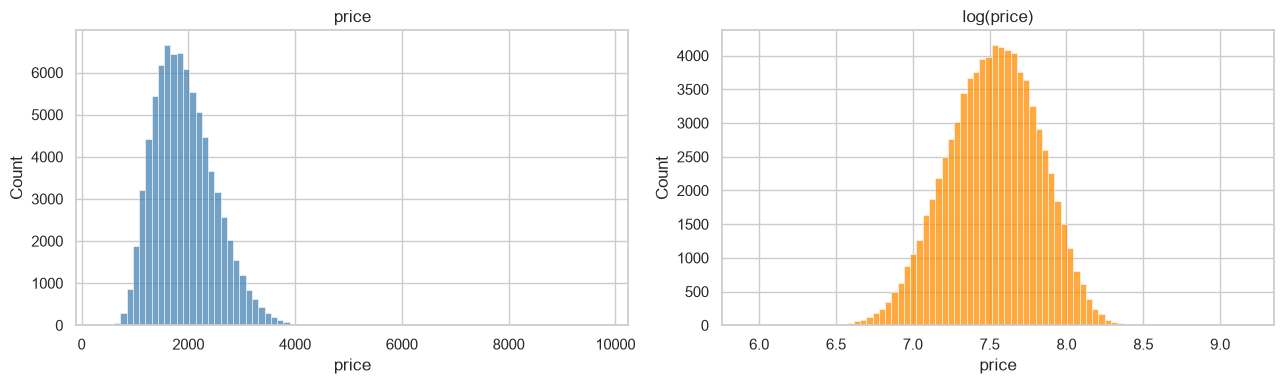

count    80000.00
mean      1929.63
std        579.59
min        372.99
1%         913.99
25%       1504.99
50%       1863.99
75%       2287.99
95%       2953.99
99%       3456.99
max       9772.99

skew: 0.958
distinct cent endings: [99] -> every price ends in .99


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df[TARGET], bins=80, ax=axes[0], color="steelblue")
axes[0].set_title("price")
sns.histplot(np.log(df[TARGET]), bins=80, ax=axes[1], color="darkorange")
axes[1].set_title("log(price)")
plt.tight_layout(); plt.show()

print(df[TARGET].describe(percentiles=[.01, .25, .5, .75, .95, .99]).round(2).to_string())
print("\nskew:", round(df[TARGET].skew(), 3))
cents = (df[TARGET] * 100 % 100).round().astype(int)
print("distinct cent endings:", cents.unique(), "-> every price ends in .99")

The target is right-skewed (skew 0.96) with a long upper tail reaching 9,772.99
against a median of 1,863.99. Every single price ends in `.99`, so the
underlying quantity is a whole number of currency units. Snapping predictions
back to `.99` would change RMSE by about 0.0002 — far too small to be worth the
extra machinery, so it is not done.

## 4. Hidden structure in the text columns

`model` and `cpu_model` look high-cardinality but are compositions of an
informative part and a random part. The test below compares the variance
explained by grouping on a column against what a purely random grouping of the
same size would explain: a ratio near 1 means noise.

In [7]:
work = df.copy()
work['model_line'] = work['model'].str.split().str[1]
work['model_code'] = work['model'].str.split().str[2]
work['cpu_family'] = work['cpu_model'].str.replace(r'[-\s]?\d{3,}$', '', regex=True).str.strip()

overall_var = work[TARGET].var()
rows = []
for col in ['model_code', 'model_line', 'cpu_family', 'brand', 'gpu_model']:
    g = work.groupby(col)[TARGET].agg(['size', 'mean'])
    between = np.average((g['mean'] - work[TARGET].mean())**2, weights=g['size'])
    expected_if_random = overall_var * (len(g) - 1) / len(work)
    rows.append({"column": col, "n_levels": len(g),
                 "between_var": between, "expected_if_noise": expected_if_random,
                 "ratio": between / expected_if_random})
pd.DataFrame(rows).round(2)

,column,n_levels,between_var,expected_if_noise,ratio
0,model_code,38215,159607.85,160461.33,0.99
1,model_line,15,5485.79,58.79,93.32
2,cpu_family,17,157584.46,67.18,2345.55
3,brand,10,27858.42,37.79,737.17
4,gpu_model,49,155546.27,201.55,771.74


`model_code` sits at a ratio of ~1.0: the three-character suffix is a random
identifier and is dropped. `model_line`, `cpu_family`, `brand` and `gpu_model`
carry real signal and are kept.

The same check on the trailing number of `cpu_model`, **conditioned on the CPU
family**, gives a ratio around 0.5 — it looks informative only because it is
confounded with the family. It is dropped too.

## 5. Structural zeros

Some zeros are not measurements but "not applicable".

In [8]:
print(pd.crosstab(df['device_type'], df['battery_wh'].eq(0)).rename(columns={False: 'battery>0', True: 'battery==0'}))
print()
print(pd.crosstab(df['device_type'], df['psu_watts'].eq(0)).rename(columns={False: 'psu>0', True: 'psu==0'}))

battery_wh   battery>0  battery==0
device_type                       
Desktop              0       32127
Laptop           47873           0

psu_watts    psu>0  psu==0
device_type               
Desktop      32127       0
Laptop           0   47873


`battery_wh` and `charger_watts` are zero for exactly every Desktop, and
`psu_watts` is zero for exactly every Laptop. Treating those zeros as numbers
would tell a linear model that a desktop has a zero-capacity battery. They are
encoded as missing plus an applicability flag.

## 6. Relationships with the target

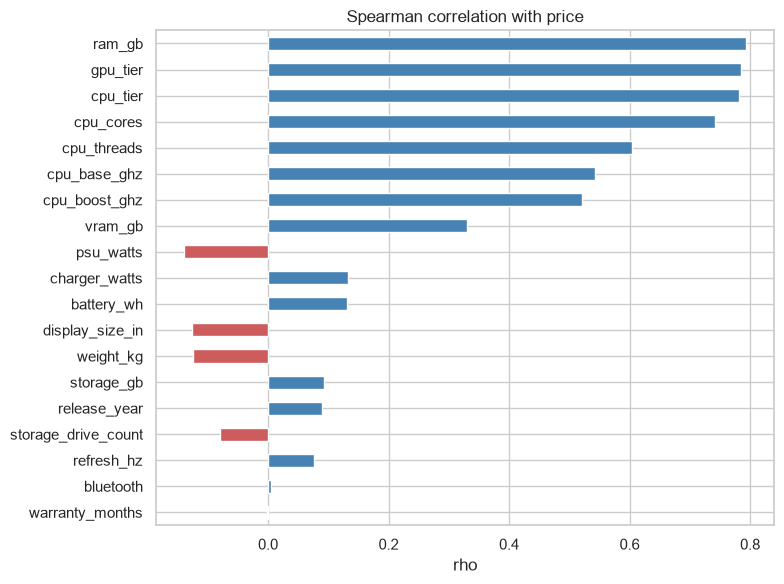

ram_gb                 0.793
gpu_tier               0.785
cpu_tier               0.781
cpu_cores              0.742
cpu_threads            0.603
cpu_base_ghz           0.543
cpu_boost_ghz          0.521
vram_gb                0.331
psu_watts             -0.139
charger_watts          0.132
battery_wh             0.131
display_size_in       -0.126
weight_kg             -0.125
storage_gb             0.094
release_year           0.089
storage_drive_count   -0.080
refresh_hz             0.076
bluetooth              0.004
warranty_months       -0.001
Name: price, dtype: float64

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(['ID', TARGET])
corr = df[list(num_cols) + [TARGET]].corr(method='spearman')[TARGET].drop(TARGET)
corr = corr.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
corr.plot.barh(ax=ax, color=np.where(corr > 0, "steelblue", "indianred"))
ax.invert_yaxis(); ax.set_title("Spearman correlation with price"); ax.set_xlabel("rho")
plt.tight_layout(); plt.show()
corr.round(3)

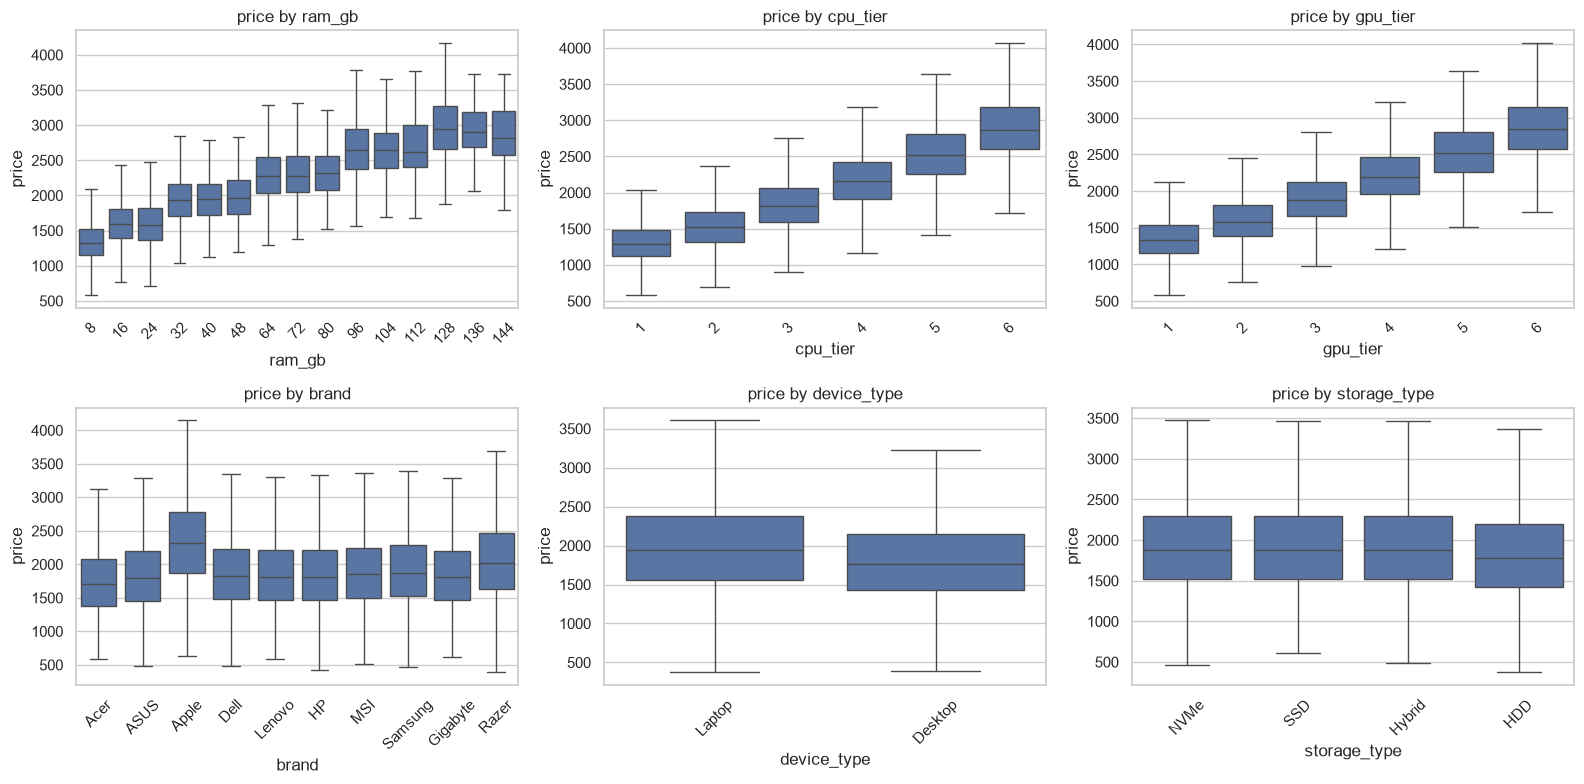

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), ['ram_gb', 'cpu_tier', 'gpu_tier', 'brand', 'device_type', 'storage_type']):
    order = None
    if df[col].dtype != object and str(df[col].dtype) not in ('str', 'string'):
        order = sorted(df[col].unique())
    sns.boxplot(data=df, x=col, y=TARGET, ax=ax, order=order, showfliers=False)
    ax.set_title(f"price by {col}")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

`ram_gb`, `gpu_tier` and `cpu_tier` dominate. Note that the response to `ram_gb`
is **not** linear in the raw value — which is why the modelling section below
compares a representation that enters numbers as single linear terms against one
that gives every observed level its own coefficient.

## 7. Validation protocol

The 80,000 rows are split once, with a fixed seed:

* **development, 64,000 rows** — every decision is made here, by 5-fold CV with
  shared folds so model comparisons are *paired*;
* **holdout, 16,000 rows** — sealed, used once, only for the official
  overfitting rule.

In [11]:
from src.data import load_dev_holdout

X_dev, y_dev, X_hold, y_hold = load_dev_holdout()
print(f"development: {X_dev.shape}   holdout: {X_hold.shape}")
print(f"mean price  dev={y_dev.mean():.2f}  holdout={y_hold.mean():.2f}")

development: (64000, 33)   holdout: (16000, 33)
mean price  dev=1928.66  holdout=1933.53


## 8. Feature engineering and baselines

Feature families are switchable so each can be measured separately.

In [12]:
from src.features import FeatureConfig, FeatureEngineer

cfg = FeatureConfig()
print("enabled families:", cfg.enabled())

engineered = FeatureEngineer(cfg).fit_transform(X_dev)
print(f"{X_dev.shape[1]} raw columns -> {engineered.shape[1]} engineered columns")
engineered.head(3)

enabled families: ['model_decomp', 'cpu_decomp', 'structural_zeros', 'resolution']


33 raw columns -> 40 engineered columns


,device_type,brand,release_year,os,form_factor,cpu_brand,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,model_line,cpu_family,has_battery,has_psu,power_watts,res_width,res_height,res_pixels,res_aspect,res_ppi
0,Desktop,Lenovo,2020,macOS,Full-Tower,AMD,5,18,36,3.2,4.1,NVIDIA,RTX 40 80,4,10,64,NVMe,512,2,LED,27.0,1920x1080,60,NaN,NaN,650.0,Wi-Fi 5,5.2,10.0,48,Station,AMD Ryzen 7,0,1,650,1920,1080,2073600,1.777778,81.589154
1,Desktop,Lenovo,2018,Linux,SFF,Intel,2,10,20,2.6,3.4,Apple,Apple Integrated,2,4,16,SSD,1024,1,QLED,32.0,1920x1080,120,NaN,NaN,650.0,Wi-Fi 6,5.0,4.0,12,Creator,Intel i5,0,1,650,1920,1080,2073600,1.777778,68.840849
2,Desktop,ASUS,2022,macOS,SFF,AMD,2,6,12,2.6,3.7,AMD,RX 7000 50,1,4,8,HDD,512,2,OLED,32.0,1920x1080,144,NaN,NaN,450.0,Wi-Fi 6,5.2,6.0,12,Creator,AMD Ryzen 5,0,1,450,1920,1080,2073600,1.777778,68.840849


In [13]:
from src.evaluate import cross_validate_model
from src.models import build_model
from src.config import CV_FOLDS

# A compact, representative re-run. The full sweep lives in experiments/exp01.
LIVE = [
    ("mean baseline",        build_model("mean")),
    ("ridge | onehot",       build_model("ridge", preprocessor="onehot", alpha=10.0)),
    ("ridge | levels_plus",  build_model("ridge", preprocessor="levels_plus", alpha=100.0)),
    ("lightgbm",             build_model("lgbm", n_estimators=400, learning_rate=0.06)),
]

live_results = []
for label, model in LIVE:
    res = cross_validate_model(model, X_dev, y_dev, name=label,
                               n_splits=CV_FOLDS, n_repeats=1, seed=RANDOM_SEED, return_oof=False)
    live_results.append({"model": label, "val_rmse": res.val_rmse, "train_rmse": res.train_rmse,
                         "gap": res.gap, "val_mae": res.val_mae})
    print(res.summary())

pd.DataFrame(live_results).round(3)

mean baseline                      valRMSE= 578.063 (+-5.559) trainRMSE= 578.070 gap= -0.007 valMAE=458.255 [6.2s]


ridge | onehot                     valRMSE= 217.240 (+-14.430) trainRMSE= 216.962 gap= +0.278 valMAE=144.052 [6.8s]


ridge | levels_plus                valRMSE= 211.920 (+-14.952) trainRMSE= 211.018 gap= +0.902 valMAE=138.841 [17.3s]


lightgbm                           valRMSE= 214.888 (+-14.501) trainRMSE= 182.369 gap=+32.518 valMAE=141.136 [15.0s]


,model,val_rmse,train_rmse,gap,val_mae
0,mean baseline,578.063,578.070,-0.007,458.255
1,ridge | onehot,217.240,216.962,0.278,144.052
2,ridge | levels_plus,211.920,211.018,0.902,138.841
3,lightgbm,214.888,182.369,32.518,141.136


Two results drive everything that follows.

1. A **linear** model is competitive with gradient boosting on this data.
2. Expanding every low-cardinality column into one dummy per level (the
   `levels_plus` representation) beats both — and does so with a train/validation
   gap of about one point, whereas LightGBM's gap is over thirty.

The full model sweep, including random forests, extra trees, XGBoost and
CatBoost, is in the experiment log.

In [14]:
from src.utils import ExperimentTracker

history = ExperimentTracker.load()
print(f"{len(history)} logged experiments")
(history.sort_values("validation_rmse")
        [["experiment_id", "model", "preprocessing", "hyperparameters",
          "train_rmse", "validation_rmse", "validation_mae", "notes"]]
        .head(15).reset_index(drop=True))

91 logged experiments


,experiment_id,model,preprocessing,hyperparameters,train_rmse,validation_rmse,validation_mae,notes
0,exp_0091,blend,mixed,"{""catboost"":0.6283,""ridge|levels_plus"":0.3717}",205.8061,210.9807,137.7257,exp09 multi-seed robustness (15 folds)
1,exp_0086,cat|native,native,"{""depth"":6,""iterations"":1500,""learning_rate"":0...",204.4304,211.1896,138.0004,exp10 catboost tuning phase 1: depth6 it1500 l...
2,exp_0077,cat,native,"{""depth"":6,""iterations"":800,""learning_rate"":0.06}",203.9738,211.2532,137.9662,exp07 ensemble candidate (OOF generated)
3,exp_0071,cat,native,"{""depth"":6,""iterations"":800,""learning_rate"":0.06}",203.9738,211.2532,137.9662,exp07 ensemble candidate (OOF generated)
4,exp_0072,blend[ridge_levels+ridge_onehot+hgb+lgbm+cat],mixed,"{""combiner"":""nnls"",""weights"":{""cat"":0.546864,""...",NaN,211.3083,NaN,exp07 best blend; gain vs best single (cat) = ...
5,exp_0078,blend[ridge_levels+ridge_onehot+hgb+lgbm+cat],mixed,"{""combiner"":""nnls"",""weights"":{""cat"":0.546864,""...",NaN,211.3083,NaN,exp07 best blend; pooled gain vs best single (...
6,exp_0082,cat|native,native,"{""depth"":4,""iterations"":1000,""learning_rate"":0...",207.3666,211.3273,138.0287,exp10 catboost tuning phase 1: depth4 it1000 l...
7,exp_0090,catboost,native,{},203.8156,211.3346,137.9606,exp09 multi-seed robustness (15 folds)
8,exp_0039,cat|native,native,"{""depth"":6,""iterations"":600,""learning_rate"":0.06}",205.6653,211.3824,138.1205,exp01b baseline completion
9,exp_0079,cat|native,native,"{""depth"":6,""iterations"":600,""learning_rate"":0.06}",205.6653,211.3824,138.1205,exp10 catboost tuning phase 1: depth6 it600 lr...


## 9. What shape is the generating process?

Three questions were asked directly (`experiments/exp02_structure.py`,
`exp06_interactions.py`, `exp08_additive_boosting.py`):

* **Is it multiplicative?** A log-space fit, with a Duan smearing correction so
  the comparison is fair, was clearly worse. The noise is additive on the price
  scale.
* **Are there interactions?** Boosting the additive model's residual made
  predictions *worse*, and the residual importances were flat and diffuse —
  the signature of noise. Explicit interaction terms were then added to the
  linear model, which is a direct test that cannot be confounded by a booster
  overfitting; see the log for the outcome.
* **Does a booster help if forced to be additive?** Tested with depth-1 trees
  and with per-feature interaction constraints.

The cell below reproduces the most important of these checks at small scale.

In [15]:
from src.evaluate import rmse
from sklearn.model_selection import train_test_split

idx_tr, idx_va = train_test_split(np.arange(len(X_dev)), test_size=0.25, random_state=RANDOM_SEED)
Xtr, Xva = X_dev.iloc[idx_tr], X_dev.iloc[idx_va]
ytr, yva = y_dev.iloc[idx_tr], y_dev.iloc[idx_va]

additive = build_model("ridge", preprocessor="levels_plus", alpha=100.0).fit(Xtr, ytr)
p_add = additive.predict(Xva)
print(f"additive Ridge            valRMSE={rmse(yva, p_add):8.3f}")

log_model = build_model("ridge", preprocessor="levels_plus", alpha=100.0, target_transform="log").fit(Xtr, ytr)
print(f"multiplicative (log space) valRMSE={rmse(yva, log_model.predict(Xva)):8.3f}")

booster = build_model("lgbm", n_estimators=1500, learning_rate=0.05, num_leaves=63).fit(Xtr, ytr)
print(f"unconstrained LightGBM     valRMSE={rmse(yva, booster.predict(Xva)):8.3f}")

additive Ridge            valRMSE= 225.688


multiplicative (log space) valRMSE= 232.655


unconstrained LightGBM     valRMSE= 232.817


## 10. The error tail

A small number of rows carry a large share of the squared error. The important
statistical caveat: a positive bias in the top decile of the **true** price is
expected even from a perfect model, because conditioning on a high `y` also
selects rows with a large positive noise draw. Calibration must be read on
deciles of the **prediction**.

In [16]:
from src.evaluate import error_concentration, residual_by_decile

pred_dev = additive.predict(Xva)
print("=== share of squared error carried by the worst rows ===")
display(error_concentration(yva, pred_dev).round(4))

print("\n=== by decile of TRUE price (selection artefact expected) ===")
display(residual_by_decile(yva, pred_dev).round(2))

resid = yva.to_numpy() - pred_dev
d = pd.qcut(pred_dev, 10, labels=False, duplicates="drop")
by_pred = pd.DataFrame({"pred": pred_dev, "err": resid, "d": d}).groupby("d").agg(
    n=("err", "size"), pred_level=("pred", "mean"),
    bias=("err", "mean"), resid_sd=("err", "std"))
print("\n=== by decile of PREDICTED price (true calibration check) ===")
display(by_pred.round(2))

=== share of squared error carried by the worst rows ===


,top_fraction,n_rows,share_of_squared_error,rmse_excluding_them
0,0.001,16,0.3846,177.0446
1,0.010,160,0.4711,164.1269
2,0.050,800,0.5996,142.8093
3,0.100,1600,0.6972,124.1996



=== by decile of TRUE price (selection artefact expected) ===


,n,y_mean,pred_mean,bias,rmse
decile,,,,,
0,1602,1089.49,1153.35,-63.86,150.36
1,1600,1340.45,1380.88,-40.43,136.86
2,1603,1501.09,1534.86,-33.76,142.33
3,1599,1642.02,1677.78,-35.76,153.39
4,1598,1789.50,1814.51,-25.00,159.86
5,1601,1937.06,1947.20,-10.14,165.55
6,1609,2100.71,2101.18,-0.47,177.02
7,1591,2285.91,2270.18,15.73,186.42
8,1599,2533.94,2500.79,33.15,196.66



=== by decile of PREDICTED price (true calibration check) ===


,n,pred_level,bias,resid_sd
d,,,,
0,1600,1114.00,13.28,134.41
1,1600,1359.67,0.24,127.57
2,1600,1521.27,2.25,162.79
3,1600,1665.23,-10.43,179.15
4,1600,1800.83,0.77,168.85
5,1600,1946.99,1.39,223.05
6,1600,2101.63,-2.62,279.49
7,1600,2285.06,-6.34,253.30
8,1600,2520.13,2.04,328.77


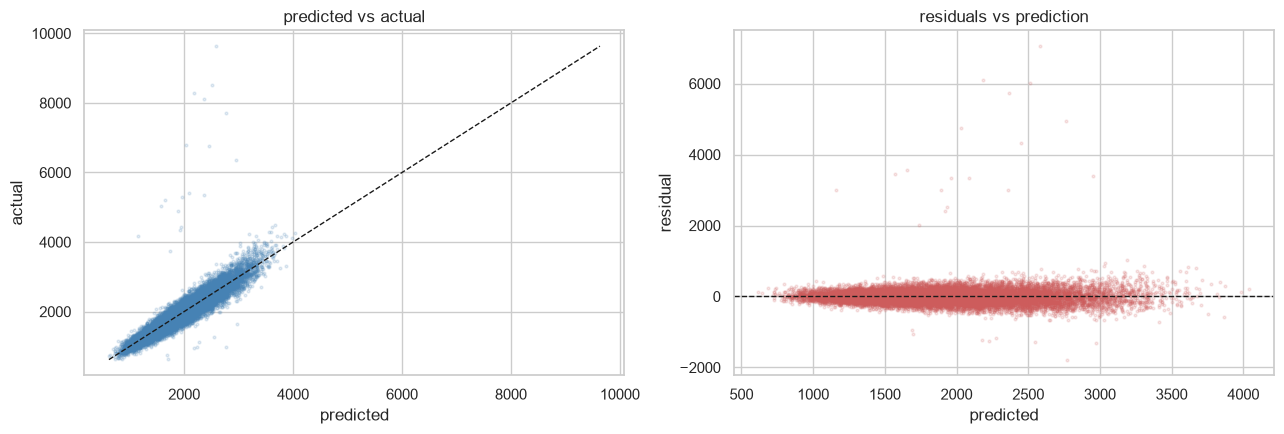

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(pred_dev, yva, s=4, alpha=0.15, color="steelblue")
lims = [min(pred_dev.min(), yva.min()), max(pred_dev.max(), yva.max())]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("actual"); axes[0].set_title("predicted vs actual")

axes[1].scatter(pred_dev, resid, s=4, alpha=0.15, color="indianred")
axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("residual"); axes[1].set_title("residuals vs prediction")
plt.tight_layout(); plt.show()

## 11. Choosing the final model

Three candidates survived the screening. The choice between them weighs
predictive accuracy, overfitting margin, stability, complexity and
explainability together, as the challenge's own criteria require — not RMSE
alone.

| | Ridge `levels_plus` | CatBoost | **blend of the two** |
|---|---|---|---|
| pooled out-of-fold RMSE | 212.34 | 211.69 | **211.33** |
| overfitting margin, mean over inner splits | +27.7 | +20.1 | +22.9 |
| overfitting margin, worst split | +25.2 | +17.5 | +20.4 |
| deterministic across refits | yes | yes | yes |
| artefact size | 24 KB | ~2 MB | ~2 MB |
| SHAP | exact (linear) | exact (tree) | exact (weighted sum) |

For contrast, an ordinary LightGBM reaches 215.5 and **fails the overfitting
rule on every inner split** (margin −13), and HistGradientBoosting passes with a
worst-case margin of only 7.5. The models that fit this data well are also the
ones that satisfy the constraint; that is not a coincidence, it is what happens
when the model form matches the process.

The blend takes 0.372 of the Ridge and 0.628 of CatBoost. Those weights were
fitted by non-negative least squares on out-of-fold predictions, and the gain
survives fitting them on rows they are not scored on.

Adding HistGradientBoosting, LightGBM and the one-hot Ridge to the blend buys
0.025 RMSE, so they are left out.

## 12. The official overfitting rule

The rule, implemented exactly as specified in `src.evaluate.overfitting_report`:
train the final model on the training split only; compute RMSE on train and on
validation; give each a 95% percentile bootstrap confidence interval by
resampling **observations** (2,000 replicates, fixed seed); compare the
intervals. Overlap means no overfitting.

In [18]:
import json
from src.train import build_from_config, load_config
from src.evaluate import overfitting_report, mae

config = load_config()
print(json.dumps(config, indent=2))

final_model = build_from_config(config)
final_model.fit(X_dev, y_dev)

pred_train = final_model.predict(X_dev)
pred_hold = final_model.predict(X_hold)

print(f"\ntrain   RMSE={rmse(y_dev, pred_train):8.3f}  MAE={mae(y_dev, pred_train):8.3f}")
print(f"holdout RMSE={rmse(y_hold, pred_hold):8.3f}  MAE={mae(y_hold, pred_hold):8.3f}")

{
  "name": "ridge-levels-plus + catboost blend",
  "description": "Fixed-weight blend of a saturated additive Ridge and CatBoost. The generating process was shown to be additive (exp02, exp06, exp06b, exp08), which is why the additive Ridge beats every gradient booster except CatBoost and carries almost no train/validation gap. CatBoost adds a little on top; blending the two recovers 0.35 RMSE over CatBoost alone and 1.01 over the Ridge alone (exp07, exp13), a gain confirmed with weights fitted on rows they were not scored on. Adding HistGradientBoosting, LightGBM or the one-hot Ridge to the blend buys 0.025 RMSE, so they are left out - and LightGBM fails the overfitting rule on its own (exp11).",
  "kind": "ensemble",
  "seed": 42,
  "feature_config": {
    "model_decomp": true,
    "cpu_decomp": true,
    "cpu_generation": false,
    "structural_zeros": true,
    "resolution": true,
    "capacity": false,
    "premium": false
  },
  "weights": [
    0.3717,
    0.6283
  ],
  "member


train   RMSE= 206.614  MAE= 135.718
holdout RMSE= 232.946  MAE= 139.821


In [19]:
report = overfitting_report(y_dev, pred_train, y_hold, pred_hold)
print(report)

train RMSE      =  206.614   95% CI [ 196.987,  216.383]
validation RMSE =  232.946   95% CI [ 209.123,  259.959]
overlap = True  margin = +7.260
verdict: no overfitting (CIs overlap)  ->  15 points


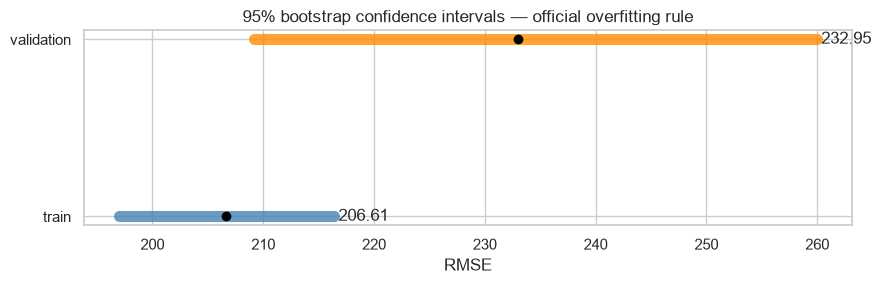

In [20]:
fig, ax = plt.subplots(figsize=(9, 3))
for i, (label, d, color) in enumerate([("train", report.train, "steelblue"),
                                       ("validation", report.validation, "darkorange")]):
    ax.plot([d["ci_low"], d["ci_high"]], [i, i], lw=8, color=color, solid_capstyle="round", alpha=.8)
    ax.plot(d["rmse"], i, "o", color="black", zorder=3)
    ax.text(d["ci_high"] + 0.4, i, f"{d['rmse']:.2f}", va="center")
ax.set_yticks([0, 1]); ax.set_yticklabels(["train", "validation"])
ax.set_xlabel("RMSE"); ax.set_title("95% bootstrap confidence intervals — official overfitting rule")
plt.tight_layout(); plt.show()

## 13. SHAP — global

SHAP attributes the model's output to its inputs. It describes **what the model
does**, not what causes prices in the world; nothing here is a causal claim.

In [21]:
from src.explain import compute_shap, global_report, local_report

# The saturated representation spreads one feature over many columns, and a
# weighted ensemble spreads it over members too. SHAP values are additive, so
# both are summed back to one number per engineered feature.
shap_result = compute_shap(final_model, X_hold, sample=1500)
print("estimator:", shap_result.estimator_name)
print("features :", shap_result.by_feature.shape[1])

ranking = global_report(shap_result)
ranking.head(20).round(2)

estimator: WeightedEnsemble[ridge_levels_plus(0.372), catboost(0.628)]
features : 40


,feature,mean_abs_shap,mean_shap
0,gpu_tier,178.54,0.93
1,display_type,110.10,-2.12
2,ram_gb,91.52,-3.98
3,cpu_tier,84.30,-0.25
4,os,81.38,-3.64
5,storage_gb,47.53,-1.10
6,form_factor,43.13,-4.34
7,brand,42.83,0.52
8,release_year,42.52,-1.71
9,cpu_brand,40.74,2.88


In [22]:
top = ranking.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top['feature'], top['mean_abs_shap'], color="steelblue")
ax.set_xlabel("mean |SHAP| (in price units)")
ax.set_title("Which features move this model's predictions most")
plt.tight_layout(); plt.show()

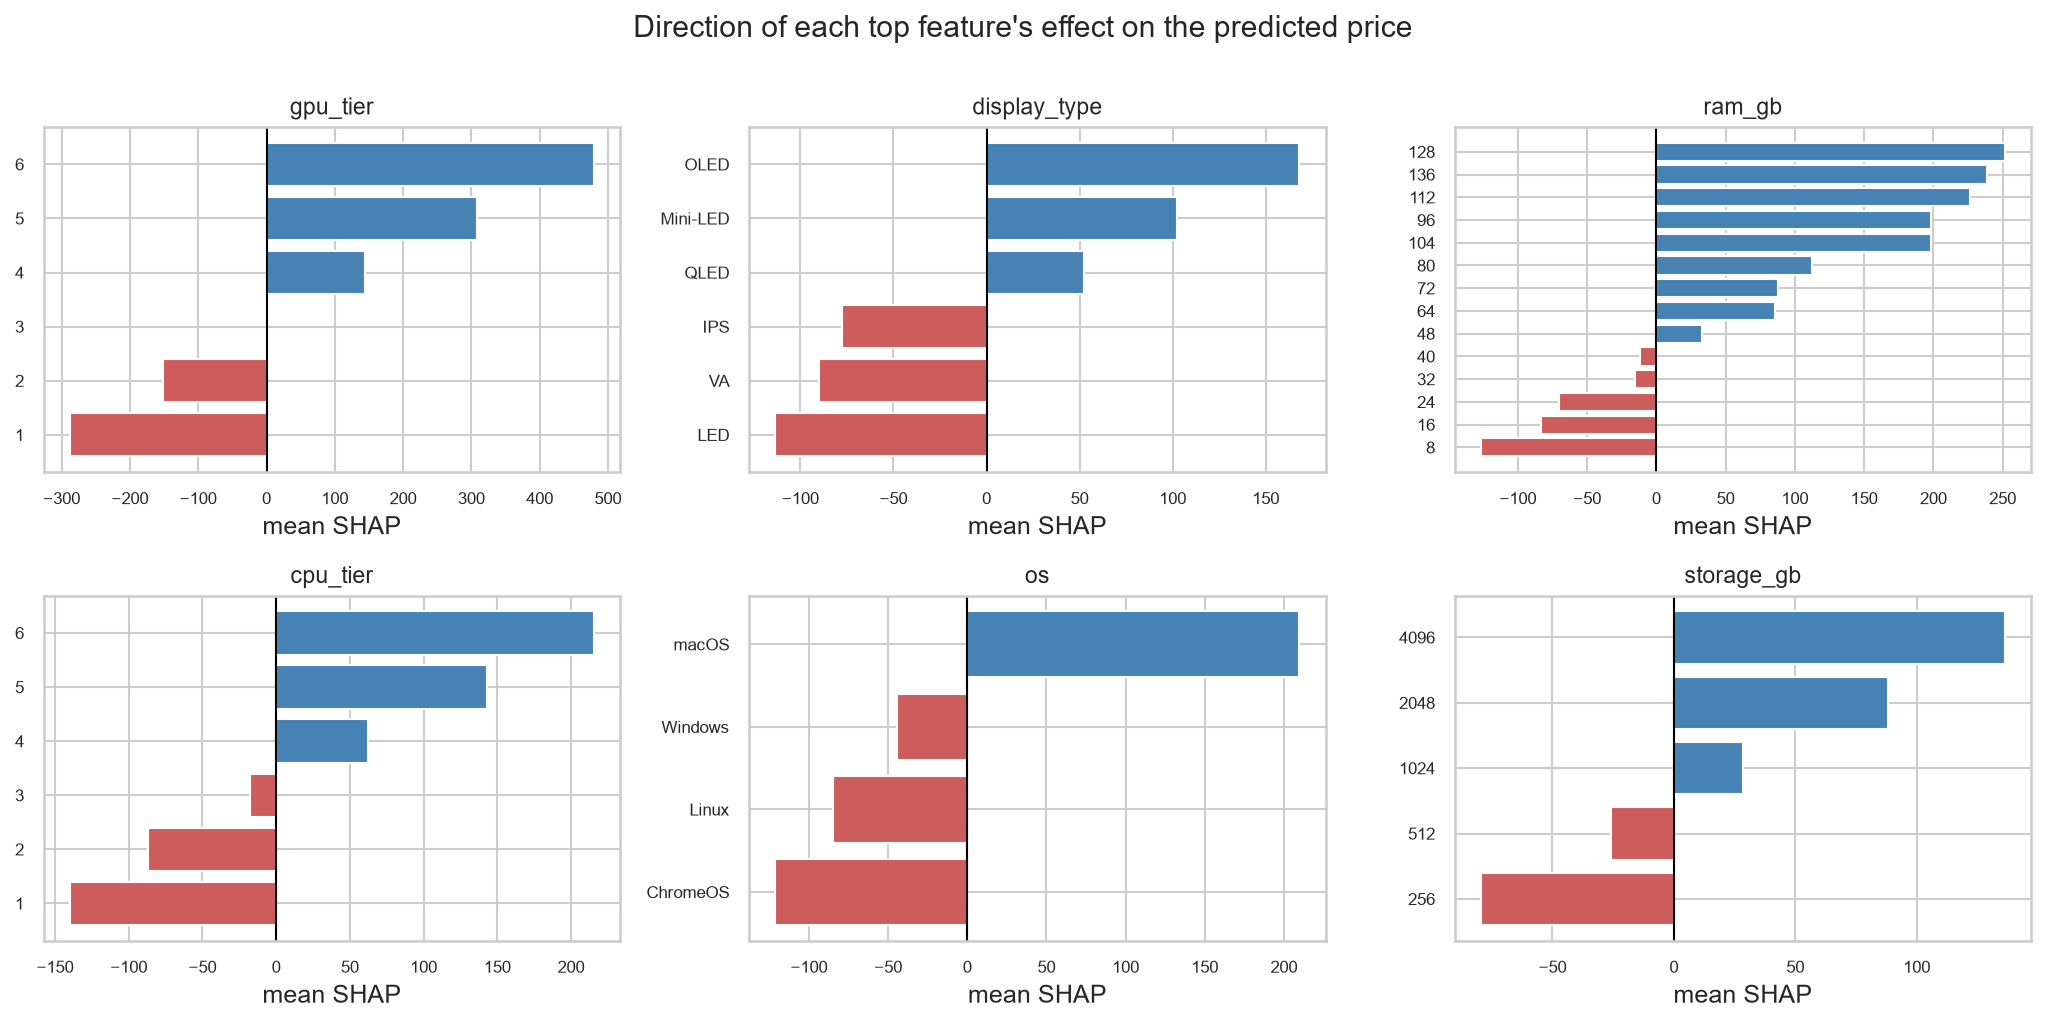

In [23]:
from src.explain import effect_by_level
from IPython.display import Image

# Importance says which features move predictions; this says in which direction.
effect_by_level(shap_result, ranking)
Image(filename=str(ROOT / "reports" / "figures" / "shap_effect_by_level.png"))

Every one of these reads the way a buyer would expect, which is a useful sanity
check on the fitted model: GPU tier and CPU tier are monotone from strongly
negative at tier 1 to strongly positive at tier 6; RAM runs from about −125 at
8 GB to +250 at 128 GB; panel technology orders LED < VA < IPS < QLED < Mini-LED
< OLED; and storage is monotone in capacity.

Note that the plot shows the model's *average* contribution per level, which is
why it is smooth even though nothing forced it to be.

The ranking is led by the component specifications — GPU tier, display type,
CPU tier and clock — which is what one would expect to drive a machine's price.

One contrast is worth pausing on. In section 6, `ram_gb` had the **highest**
rank correlation with price (0.79), yet here it sits well below `gpu_tier`.
There is no contradiction: a correlation is *marginal*, measuring `ram_gb`
against price while ignoring everything else, and machines with a lot of RAM
also tend to have a strong GPU and a fast CPU. SHAP is *conditional*: it asks
what `ram_gb` adds once the rest of the specification is already known, and the
answer is much less. The two numbers answer different questions.

Read all of this as a description of the fitted model's behaviour — which inputs
it leans on — not as evidence about what causes prices in the market.

## 14. SHAP — local

One individual prediction, decomposed into the features that pushed it up and
those that pushed it down.

In [24]:
ROW = 0
base, contrib = local_report(shap_result, row=ROW)
print(f"base value (mean prediction) = {base:.2f}")
print(f"model prediction             = {shap_result.prediction(ROW):.2f}\n")

print("pushing the prediction UP:")
display(contrib[contrib['shap'] > 0].head(8)[['feature', 'value', 'shap']].round(2))
print("\npushing the prediction DOWN:")
display(contrib[contrib['shap'] < 0].head(8)[['feature', 'value', 'shap']].round(2))

base value (mean prediction) = 1929.73
model prediction             = 1388.14

pushing the prediction UP:


,feature,value,shap
4,refresh_hz,165,63.57
10,res_height,1600,30.73
11,storage_gb,1024,29.55
12,res_pixels,4096000,21.76
13,cpu_threads,12,19.63
15,res_ppi,188.679623,14.88
16,storage_type,NVMe,13.58
17,charger_watts,120.0,12.24



pushing the prediction DOWN:


,feature,value,shap
0,gpu_tier,1,-289.74
1,ram_gb,8,-126.41
2,cpu_tier,2,-84.41
3,display_type,IPS,-79.25
5,os,Windows,-46.50
6,form_factor,Mainstream,-43.74
7,cpu_base_ghz,2.2,-40.72
8,release_year,2021,-34.81


In [25]:
head = contrib.head(14).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh([f"{f} = {v}" for f, v in zip(head['feature'], head['value'])],
        head['shap'], color=np.where(head['shap'] < 0, "indianred", "steelblue"))
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("contribution to the predicted price")
ax.set_title(f"Why the model predicted {shap_result.prediction(ROW):,.0f} for observation {ROW}")
plt.tight_layout(); plt.show()

**How to read this.** The model starts from the base value — its average
prediction over the sample — and then adds or subtracts an amount for each
specification of this particular machine. Positive bars are the features that
pushed this prediction above the average; negative bars are the ones that pulled
it below. The bars sum exactly to the difference between the base value and the
final prediction, which is the property the tests in `tests/test_explain.py`
check to within 1e-6.

For the machine shown above, the strongest movers are the GPU and CPU tiers, the
storage configuration and the display type — the components a buyer would
recognise as driving the price. Whether each one pushes up or down depends on
whether this machine's value for it is above or below what is typical.

Again, this is the model's internal accounting for one row. It says what the
model did, not what causes prices in the computer market.

## 15. Inference on new data

The delivered artefact is a single pipeline: raw columns in, predictions out.
No manual preprocessing, no retraining.

In [26]:
import joblib
from src.config import FINAL_MODEL_PATH
from src.inference import predict_frame

joblib.dump(final_model, FINAL_MODEL_PATH)
reloaded = joblib.load(FINAL_MODEL_PATH)

# Simulate "new data": holdout rows, target column dropped, order shuffled.
new_data = X_hold.sample(frac=1.0, random_state=0).reset_index(drop=True)
preds = predict_frame(new_data, model=reloaded)

print(f"{len(preds)} predictions for {len(new_data)} input rows")
print(f"order preserved: {len(preds) == len(new_data) and list(preds.index) == list(new_data.index)}")
preds.head()

16000 predictions for 16000 input rows
order preserved: True


0    1529.748824
1    1693.170392
2    2506.913853
3    1366.243390
4     694.584343
Name: predicted_price, dtype: float64

## 16. Conclusion

**What the data turned out to be.** The price is close to a sum of
per-component contributions. Three independent tests agree: boosting the
additive model's residual makes it worse with flat, diffuse importances;
explicit interaction terms produce changes of at most 0.13 RMSE and hurt when
combined; and forcing a booster to be additive improves it by 5.3 points. A
log-space fit is clearly worse, so the noise is additive on the price scale.

**What that implied for modelling.** A saturated additive linear model — one
coefficient per observed level of each feature — outperformed random forests,
extra trees, XGBoost, LightGBM and HistGradientBoosting, all of which spend
capacity on interactions the data does not contain. CatBoost was the exception,
and blending the two is better than either alone, by a margin that survives
fitting the weights out of sample.

**Why the same choice wins on the other criteria.** Because the model form
matches the process, training and validation errors nearly coincide, so the
bootstrap intervals overlap with room to spare rather than marginally. The
contrast is stark: an ordinary LightGBM, only 4 RMSE points behind, **fails the
overfitting criterion on every split tested**. Here there was no trade-off to
make between accuracy and the constraint — but there would have been, had the
data been different, and that is why the margin was measured rather than
assumed.

**What was ruled out, with evidence.** Multiplicative structure; interactions;
a tail correction — the apparent bias among expensive machines is a selection
artefact of conditioning on the true target, and the calibration measured on
deciles of the *prediction* is flat. All of the engineered feature families
turned out to be redundant under the saturated representation, which is worth
saying plainly: the gain came from the representation, not from the feature
engineering.

**Honest limitations.** The remaining error is, as far as these experiments can
tell, irreducible noise. Its spread is proportional to price at about 11% with
an extremely heavy right tail, the worst 0.1% of rows carry 38% of all squared
error while belonging to no identifiable segment, and the model's RMSE already
equals the RMSE that this noise alone implies. A flexible booster drives
training error far below the additive model's while making validation error
worse — the signature of fitting noise.

The secret test set is assumed to share the development distribution. That is a
working hypothesis, not a guarantee, and no modelling choice here depends on how
the data was split.